[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ZeruiW/frontier-ai-courses/blob/main/C00_VLM_Multimodal_Course/01_foundations/01_vision_encoders.ipynb)

# 01 · 多模态基础与视觉编码器 (Vision Encoders)

**配套讲解**：`01_讲解.html` · **算力**：CPU 可跑（下载 ~350MB 模型），有 GPU 更快

本 notebook 动手验证讲解里的核心机制：

1. 一张图如何被切成 **patch** 并变成 token 序列
2. 加载真实 **ViT** (`google/vit-base-patch16-224`)，看它的输出形状：`[CLS]` + patch tokens
3. 可视化 **self-attention**（attention rollout），看模型在"看"哪里
4. 对比 **CLIP 视觉编码器** 与监督 ViT —— 同样结构、不同预训练
5. **3 道 ✏️ 练习**（手写 patchify / ViT token 账本 / attention rollout 的 numpy 复现），附参考答案

> 核心 takeaway：**VLM 真正喂给 LLM 的是那一串 patch token，不是单个 `[CLS]` 向量。**

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"使用设备 device = {device}")
print(f"torch version = {torch.__version__}")

使用设备 device = cpu
torch version = 2.11.0+cpu


## 1. 准备一张样例图

用 COCO 的经典 "两只猫" 图（HuggingFace 文档同款）。若无网络，可换成本地任意图片。

图像尺寸: (224, 224)


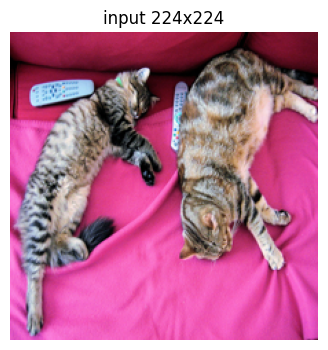

In [2]:
url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")
image = image.resize((224, 224))   # ViT-base/16 的标准输入
print("图像尺寸:", image.size)
plt.figure(figsize=(4, 4)); plt.imshow(image); plt.axis("off"); plt.title("input 224x224"); plt.show()

## 2. 把图像切成 patch —— 手动复现 "Patch Embedding" 的第一步

ViT-base/16：patch 大小 `P=16`，224/16 = 14，所以共 `14×14 = 196` 个 patch。
下面手动切块并画出 14×14 的网格，直观看到"图像被当成了 196 个词"。

patch 网格: 14x14 = 196 个 patch, 每个 16x16x3 = 768 维


/tmp/ipykernel_9421/1760835784.py:11: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.suptitle("一张图 = 196 个 patch token（外加 1 个 [CLS]）"); plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1760835784.py:11: UserWarning: Glyph 24352 (\N{CJK UNIFIED IDEOGRAPH-5F20}) missing from font(s) DejaVu Sans.
  plt.suptitle("一张图 = 196 个 patch token（外加 1 个 [CLS]）"); plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1760835784.py:11: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.suptitle("一张图 = 196 个 patch token（外加 1 个 [CLS]）"); plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1760835784.py:11: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.suptitle("一张图 = 196 个 patch token（外加 1 个 [CLS]）"); plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1760835784.py:11: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans

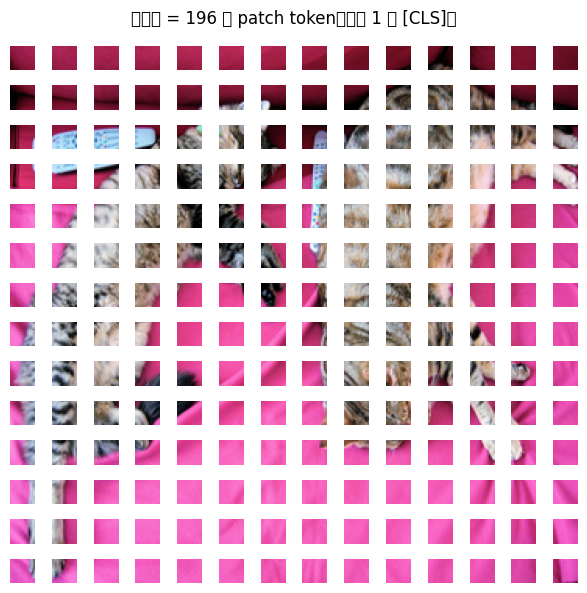

In [3]:
P = 16
arr = np.array(image)                       # (224, 224, 3)
n_side = arr.shape[0] // P                   # 14
patches = arr.reshape(n_side, P, n_side, P, 3).swapaxes(1, 2)   # (14,14,16,16,3)
print(f"patch 网格: {n_side}x{n_side} = {n_side*n_side} 个 patch, 每个 {P}x{P}x3 = {P*P*3} 维")

fig, axes = plt.subplots(n_side, n_side, figsize=(6, 6))
for i in range(n_side):
    for j in range(n_side):
        axes[i, j].imshow(patches[i, j]); axes[i, j].axis("off")
plt.suptitle("一张图 = 196 个 patch token（外加 1 个 [CLS]）"); plt.tight_layout(); plt.show()

## 3. 加载真实 ViT，看输出形状

`google/vit-base-patch16-224`：12 层、hidden=768、12 头。
关注输出 `last_hidden_state` 的形状应为 `[1, 197, 768]`：

- `197 = 1 ([CLS]) + 196 (patches)`
- `768` = 每个 token 的维度 `d`

In [4]:
from transformers import ViTImageProcessor, ViTModel

ckpt = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(ckpt)
vit = ViTModel.from_pretrained(ckpt, attn_implementation="eager").to(device).eval()

inputs = processor(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    out = vit(**inputs, output_attentions=True)

hs = out.last_hidden_state
print("last_hidden_state:", tuple(hs.shape), "  <- [batch, 1+196, 768]")
print("[CLS] 全局向量:", tuple(hs[:, 0].shape))
print("196 个 patch token (VLM 真正喂给 LLM 的):", tuple(hs[:, 1:].shape))
print("注意力层数:", len(out.attentions), "  每层形状:", tuple(out.attentions[0].shape), "[batch,heads,seq,seq]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


last_hidden_state: (1, 197, 768)   <- [batch, 1+196, 768]
[CLS] 全局向量: (1, 768)
196 个 patch token (VLM 真正喂给 LLM 的): (1, 196, 768)
注意力层数: 12   每层形状: (1, 12, 197, 197) [batch,heads,seq,seq]


## 4. 可视化 self-attention：模型在看哪里？

用 **attention rollout** [Abnar & Zuidema 2020]：把每层注意力平均头、加单位阵（残差连接）、归一化后逐层相乘，
再取 `[CLS]` 对 196 个 patch 的注意力，reshape 成 14×14 叠回原图。

/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 24847 (\N{CJK UNIFIED IDEOGRAPH-610F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/1527192482.py:21: UserWarning: Glyph 21472 (\N{CJK UNIFIED IDEOGRAPH-53E0}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_9421/15

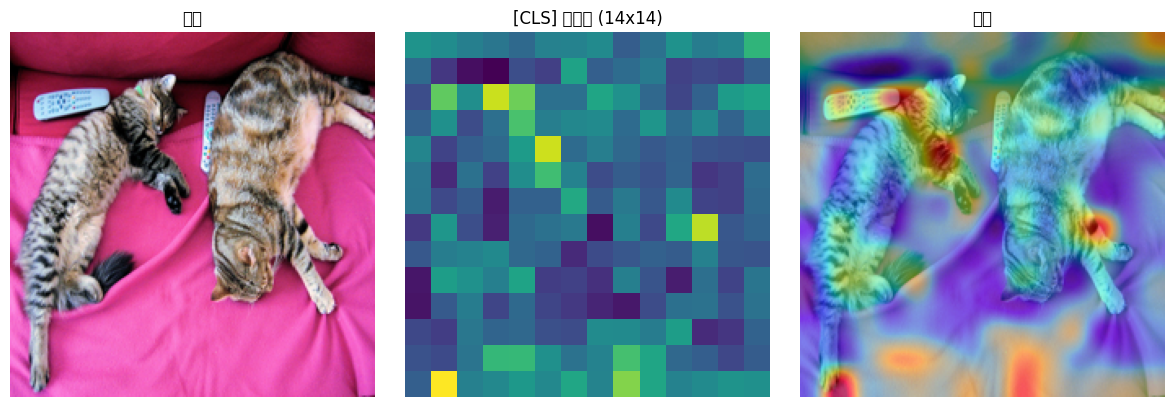

亮的区域 = [CLS] 聚合全图表征时最关注的位置（通常落在显著物体上）


In [5]:
def attention_rollout(attentions):
    # attentions: tuple(L) of [batch, heads, seq, seq]
    result = torch.eye(attentions[0].size(-1))
    for attn in attentions:
        a = attn.mean(dim=1)[0].cpu()          # 平均所有头 -> [seq, seq]
        a = a + torch.eye(a.size(-1))          # 加残差
        a = a / a.sum(dim=-1, keepdim=True)    # 行归一化
        result = a @ result                    # 逐层相乘
    return result

roll = attention_rollout(out.attentions)
cls_to_patches = roll[0, 1:]                   # [CLS] -> 196 patches
mask = cls_to_patches.reshape(14, 14).numpy()
mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
mask_up = np.array(Image.fromarray((mask * 255).astype(np.uint8)).resize((224, 224)))

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(image); ax[0].set_title("原图"); ax[0].axis("off")
ax[1].imshow(mask, cmap="viridis"); ax[1].set_title("[CLS] 注意力 (14x14)"); ax[1].axis("off")
ax[2].imshow(image); ax[2].imshow(mask_up, cmap="jet", alpha=0.5); ax[2].set_title("叠加"); ax[2].axis("off")
plt.tight_layout(); plt.show()
print("亮的区域 = [CLS] 聚合全图表征时最关注的位置（通常落在显著物体上）")

## 5. 同样的 ViT 结构，不同预训练 → 不同表征

加载 **CLIP 的视觉编码器** 和监督 ViT，对比它们的 patch token 数与维度。
两者结构几乎一致，但 CLIP 的特征是"与语言对齐过的"——这正是 VLM 偏爱它的原因（详见模块 02）。

In [6]:
from transformers import CLIPVisionModel, CLIPImageProcessor

clip_ckpt = "openai/clip-vit-base-patch32"
clip_proc = CLIPImageProcessor.from_pretrained(clip_ckpt)
clip_vis = CLIPVisionModel.from_pretrained(clip_ckpt).to(device).eval()

clip_in = clip_proc(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    clip_out = clip_vis(**clip_in)

print("=== 监督 ViT (patch16-224) ===")
print("  patch tokens:", tuple(hs[:, 1:].shape))
print("=== CLIP ViT (patch32-224) ===")
print("  patch tokens:", tuple(clip_out.last_hidden_state[:, 1:].shape), " (patch32 -> 7x7=49 个)")
print("\n要点：patch 越大 -> token 越少 -> 越省 LLM 上下文，但细节越粗。")
print("      这条 token 数 vs 细节 的权衡贯穿整个课程（见模块 06）。")

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

=== 监督 ViT (patch16-224) ===
  patch tokens: (1, 196, 768)
=== CLIP ViT (patch32-224) ===
  patch tokens: (1, 49, 768)  (patch32 -> 7x7=49 个)

要点：patch 越大 -> token 越少 -> 越省 LLM 上下文，但细节越粗。
      这条 token 数 vs 细节 的权衡贯穿整个课程（见模块 06）。


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

---
## ✏️ 练习 1：手写 `patchify_ex`

不翻上文，自己实现第 2 节的 patch 切分：输入 `(H, W, C)` 的 numpy 图像数组和 patch 大小 `P`（保证 H、W 能被 P 整除），返回形状 `(N, P*P*C)` 的 patch 序列，`N = (H//P) * (W//P)`，patch 按**行优先**排列（先从左到右、再从上到下），每个 patch 内部按行展平——这正是 ViT patch embedding 拿到的 token 顺序。

**提示**：核心是 `reshape(nh, P, nw, P, C)` 后用 `swapaxes(1, 2)` 把同一 patch 的像素聚到一起，再 reshape 成 `(N, P*P*C)`。注意直接 `reshape(N, -1)` 不 swap 会把不同 patch 的像素行混在一起——自测第 3 条专门抓这个错。5 行以内。

In [ ]:
def patchify_ex(img, P):
    # TODO: img 为 (H, W, C) numpy 数组，返回 (N, P*P*C) 的 patch 序列
    #   N = (H//P) * (W//P)，patch 按行优先排列（先左到右、再上到下）
    raise NotImplementedError

In [ ]:
# —— 练习 1 自测 ——
import numpy as np

img = np.arange(4 * 6 * 3).reshape(4, 6, 3)                  # 现造一张 4x6 的"小图"
seq = patchify_ex(img, 2)
assert seq.shape == (6, 12)                                  # (4//2)*(6//2)=6 个 patch，每个 2*2*3=12 维
assert np.array_equal(seq[0], img[0:2, 0:2].reshape(-1))     # patch 0 = 左上角块按行展平
assert np.array_equal(seq[1], img[0:2, 2:4].reshape(-1))     # 行优先：patch 1 在右边，不是下面
assert np.array_equal(seq[3], img[2:4, 0:2].reshape(-1))     # 第二行 patch 从这里开始
big = patchify_ex(np.zeros((224, 224, 3)), 16)
assert big.shape == (196, 768)                               # ViT-base/16：196 个 patch，16*16*3 恰好 = 768
print("✅ 练习 1 通过")

## ✏️ 练习 2：实现 `vit_token_stats`

ViT 的"账"要会算：实现 `vit_token_stats(img_size, patch_size, dim)`，返回四元组 `(n_patches, n_tokens, patch_embed_params, pos_embed_params)`：

- `n_patches = (img_size // patch_size) ** 2`（输入为正方形 RGB 图）
- `n_tokens = n_patches + 1`（加 1 个 `[CLS]`）
- `patch_embed_params`：把 `P*P*3` 维像素投到 `dim` 维的线性层参数量（**权重 + bias**）
- `pos_embed_params`：每个 token（含 `[CLS]`）一个 `dim` 维可学习位置向量

**提示**：纯算术，约 5 行。算完体会两件事：分辨率 224→384（patch16）时 token 数 197→577——这就是高分辨率 VLM 序列暴涨的根源；CLIP 的 patch32 在 224 输入下只有 49 个 patch（第 5 节亲眼见过 50 = 49 + 1）。

In [ ]:
def vit_token_stats(img_size, patch_size, dim):
    # TODO: 返回 (n_patches, n_tokens, patch_embed_params, pos_embed_params)
    #   patch_embed: 线性层 (P*P*3 -> dim)，参数量 = 权重 + bias
    #   pos_embed: 每个 token（含 [CLS]）一个 dim 维向量
    raise NotImplementedError

In [ ]:
# —— 练习 2 自测 ——
assert vit_token_stats(224, 16, 768) == (196, 197, 590592, 151296)   # ViT-base/16 @ 224：第 3 节的 [1, 197, 768]
assert vit_token_stats(384, 16, 768)[1] == 577                       # 224→384：197→577，序列暴涨
assert vit_token_stats(224, 32, 768)[:2] == (49, 50)                 # CLIP patch32：第 5 节见过的 50 个 token
assert vit_token_stats(224, 16, 768)[2] == 16 * 16 * 3 * 768 + 768   # 权重 + bias 口径
print("✅ 练习 2 通过")

## ✏️ 练习 3：用 numpy 复现 `attention_rollout`

把第 4 节的 attention rollout 从 torch 翻译成纯 numpy：`attention_rollout_ex(attentions)` 接收一个 list，每个元素是某一层**已对 head 取平均**的注意力矩阵（`(seq, seq)` 非负 numpy 数组），返回 rollout 结果矩阵。

**提示**：`result` 初始为单位阵，然后逐层三步——`a = a + I`（残差连接）→ 按行归一化 `a / a.sum(-1, keepdims=True)` → `result = a @ result`（**新的一层乘在左边**）。约 8 行。两条性质帮你自查：输出每行和恒为 1（每行是一个概率分布）；恒等注意力 rollout 之后仍是恒等。

In [ ]:
def attention_rollout_ex(attentions):
    # TODO: attentions 为 list of (seq, seq) 非负 numpy 矩阵（已平均所有 head）
    #   每层：加单位阵（残差）-> 行归一化 -> 左乘累积到 result
    raise NotImplementedError

In [ ]:
# —— 练习 3 自测 ——
import numpy as np

I3 = np.eye(3)
assert np.allclose(attention_rollout_ex([I3, I3]), I3)               # 恒等注意力 → rollout 仍是恒等
uni = np.ones((4, 4)) / 4                                            # 每个 token 均匀看所有 token
roll = attention_rollout_ex([uni])
assert np.allclose(roll, (uni + np.eye(4)) / 2)                      # 单层手算：(A+I) 行和为 2，归一化即除 2
assert np.allclose(roll.sum(axis=-1), 1.0)                           # 每行是概率分布
rng = np.random.default_rng(0)
a1, a2 = rng.random((5, 5)), rng.random((5, 5))
n1 = a1 + np.eye(5); n1 = n1 / n1.sum(axis=-1, keepdims=True)
n2 = a2 + np.eye(5); n2 = n2 / n2.sum(axis=-1, keepdims=True)
assert np.allclose(attention_rollout_ex([a1, a2]), n2 @ n1)          # 层顺序：后面的层乘在左边
print("✅ 练习 3 通过")

---
## 📖 参考答案

In [ ]:
# 练习 1 参考答案（先自己做，再对照）
def patchify_ex(img, P):
    H, W, C = img.shape
    nh, nw = H // P, W // P
    return img.reshape(nh, P, nw, P, C).swapaxes(1, 2).reshape(nh * nw, P * P * C)

In [ ]:
# 练习 2 参考答案（先自己做，再对照）
def vit_token_stats(img_size, patch_size, dim):
    n_patches = (img_size // patch_size) ** 2
    n_tokens = n_patches + 1
    patch_embed_params = patch_size * patch_size * 3 * dim + dim
    pos_embed_params = n_tokens * dim
    return n_patches, n_tokens, patch_embed_params, pos_embed_params

In [ ]:
# 练习 3 参考答案（先自己做，再对照）
def attention_rollout_ex(attentions):
    seq = attentions[0].shape[-1]
    result = np.eye(seq)
    for a in attentions:
        a = a + np.eye(seq)
        a = a / a.sum(axis=-1, keepdims=True)
        result = a @ result
    return result

## 6. 小结与练习

**你刚刚验证了：**
- 一张 224 图 → 196 个 patch token + 1 个 `[CLS]`，维度 768
- ViT 输出的 `last_hidden_state[:, 1:]` 就是未来要喂给 LLM 的视觉 token
- attention rollout 让我们能"看见"模型关注哪里 —— 这是评测/调试 VLM 视觉能力的基本功
- 同构 ViT 在不同预训练下表征不同；CLIP 式编码器与语言对齐，是 VLM 标配

**练习（建议动手）：**
1. 换一张含小文字的图（如截图/发票），对比 patch16 vs patch32 谁的注意力更聚焦细节 —— 体会分辨率瓶颈。
2. 把 `image.resize((224,224))` 改成 `(384,384)` 并换 `patch16-384` 模型，数一数 patch token 变成多少。
3. 取出 `hs[:,1:]`，对 196 个 patch 向量做 PCA 到 3 维当 RGB 画出来，观察语义分块。

➡️ 下一站：**模块 02 — CLIP / SigLIP**，搞懂"与语言对齐"到底是怎么训出来的。

---
## 🎯 真实数据胶囊题：真实图像的 patchify（ViT 的第一步）

ViT 把图像切成不重叠的 patch、拉平成 token。下载真实图像，实现 patchify，验证 patch 数 = (H/P)·(W/P)、每个 patch 维度 = P·P·3。

> 本模块新增的**真实数据**练习：用**真实图像**把本章方法跑一遍。先做 TODO，`assert` 全过即通关，文末有参考答案。

In [ ]:
import os, io, urllib.request
import numpy as np
import matplotlib.image as mpimg
CACHE=os.path.expanduser("~/.vlm_data"); os.makedirs(CACHE,exist_ok=True)
def real_image():
    "真实图像 Grace Hopper (来自 matplotlib 示例数据), 返回 (H,W,3) uint8"
    p=os.path.join(CACHE,"grace_hopper.jpg")
    if not os.path.exists(p):
        urllib.request.urlretrieve("https://raw.githubusercontent.com/matplotlib/matplotlib/main/lib/matplotlib/mpl-data/sample_data/grace_hopper.jpg", p)
    return mpimg.imread(p)

img=real_image()
print("真实图像:", img.shape, img.dtype)

**练习**：实现 `patchify(img, P)`：把 `(H,W,3)` 图像切成 `P×P` patch，返回 `(n_patches, P*P*3)` 数组（H、W 截断到 P 的整数倍）。

In [ ]:
def patchify(img, P=16):
    # TODO: 裁到 P 整数倍；切成 (H//P)*(W//P) 个 patch，每个拉平为 P*P*3
    raise NotImplementedError


In [ ]:
# 自测
P=16; patches=patchify(img, P)
H,W=img.shape[0]//P*P, img.shape[1]//P*P
assert patches.shape==((H//P)*(W//P), P*P*3), f"patch 形状不对: {patches.shape}"
# 更大 patch -> 更少 token
assert patchify(img,32).shape[0] < patches.shape[0]
print(f"patchify ✓  {img.shape[:2]} -P{P}-> {patches.shape[0]} 个 patch, 每个 {patches.shape[1]} 维")


### 📖 参考答案

In [ ]:
def patchify(img, P=16):
    H=img.shape[0]//P*P; W=img.shape[1]//P*P; img=img[:H,:W]
    out=[]
    for i in range(0,H,P):
        for j in range(0,W,P):
            out.append(img[i:i+P, j:j+P].reshape(-1))
    return np.array(out, dtype=float)
print("✓ patchify + 线性投影 = ViT 的 patch embedding")